importing the necessary libraries and making sure tensorflow is using the dedicated gpu

In [20]:
import tensorflow as tf 
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, UpSampling2D, Input
from tensorflow.keras.models import Model 
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt 


#comment out or remove this line if not using GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [27]:
#loading the data 

train_data = image_dataset_from_directory(
    directory = "cats", 
    image_size = (128, 128), 
    labels = None, 
    color_mode = 'rgb', 
    batch_size = 4
)
train_data = train_data.map(lambda x: (x, x))
test_data = image_dataset_from_directory(
    directory = "cat_test", 
    image_size = (128, 128), 
    labels = None, 
    color_mode = 'rgb', 
    batch_size = 4
)
test_data = test_data.map(lambda x: (x, x))

Found 31 files.
Found 5 files.


In [30]:
inp_layer = Input(shape = (128, 128, 3))
conv_layer = Conv2D(filters = 32, kernel_size = (2, 2,), activation = 'relu', padding = 'same')(inp_layer)
transpose_conv = Conv2DTranspose(filters = 1, kernel_size = (2, 2), activation = 'relu', padding = 'same')(conv_layer)
model = Model(inputs = inp_layer, outputs = transpose_conv)

model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['accuracy'])
model.fit(train_data, epochs = 10)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.0154 - loss: 22538.2852
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0150 - loss: 9649.4375      
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0155 - loss: 2359.1770 
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0153 - loss: 1231.6875    
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0154 - loss: 1488.3645    
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 1086.4059
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0156 - loss: 1004.3253
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0156 - loss: 1000.9357 
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0156 - loss: 952.6875     
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0156 - loss: 943.1226     


In [33]:
y = []
y = model.predict(test_data)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


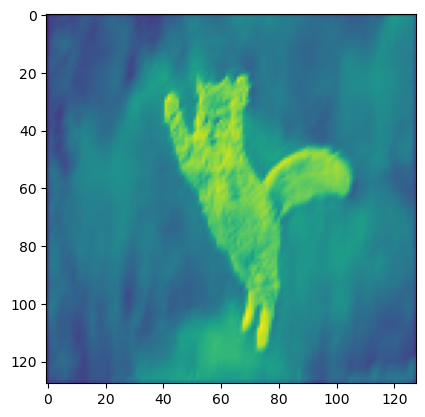

In [36]:
plt.imshow(y[1])